In [1]:
import os
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [2]:
class MumbaiSatelliteDataset(Dataset):
    def __init__(self, data_dir, shuffle=True):
        self.clean_dir = os.path.join(data_dir, "clean")
        self.corrupted_dir = next(
            os.path.join(data_dir, folder)
            for folder in ("corr", "corrupted")
            if os.path.isdir(os.path.join(data_dir, folder))
        )
        self.masks_dir = next(
            os.path.join(data_dir, folder)
            for folder in ("masked", "masks")
            if os.path.isdir(os.path.join(data_dir, folder))
        )
        self.files = sorted(
            name for name in os.listdir(self.clean_dir)
            if name.lower().endswith(".png")
        )
        self.shuffle = shuffle

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        clean = np.asarray(
            Image.open(os.path.join(self.clean_dir, fname)).convert("RGB"),
            dtype=np.float32,
        ) / 255.0
        corrupted = np.asarray(
            Image.open(os.path.join(self.corrupted_dir, fname)).convert("RGB"),
            dtype=np.float32,
        ) / 255.0
        mask = np.asarray(
            Image.open(os.path.join(self.masks_dir, fname)).convert("L"),
            dtype=np.float32,
        ) / 255.0
        mask = np.expand_dims(mask, axis=-1)
        inputs = np.concatenate([corrupted, mask], axis=-1)

        inputs = np.ascontiguousarray(np.transpose(inputs, (2, 0, 1)))
        clean = np.ascontiguousarray(np.transpose(clean, (2, 0, 1)))
        mask = np.ascontiguousarray(np.transpose(mask, (2, 0, 1)))

        return (
            torch.from_numpy(inputs),
            torch.from_numpy(clean),
            torch.from_numpy(mask),
        )


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.layers(x)


class SatelliteInpaintingUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=3):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.output_layer = nn.Conv2d(32, out_channels, kernel_size=1)

    @staticmethod
    def _match_size(x, skip):
        if x.shape[-2:] != skip.shape[-2:]:
            x = nn.functional.interpolate(
                x, size=skip.shape[-2:], mode="bilinear", align_corners=False
            )
        return x

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        bottleneck = self.bottleneck(self.pool(e3))

        d3 = self._match_size(self.up3(bottleneck), e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self._match_size(self.up2(d3), e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self._match_size(self.up1(d2), e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.output_layer(d1))


def compute_inpainting_loss(pred, target, mask, hole_weight=6.0, valid_weight=1.0):
    hole_loss = torch.mean(torch.abs((pred - target) * (1.0 - mask)))
    valid_loss = torch.mean(torch.abs((pred - target) * mask))
    return hole_weight * hole_loss + valid_weight * valid_loss


def calculate_psnr(pred, gt):
    if torch.is_tensor(pred):
        pred = pred.detach().cpu().numpy()
    if torch.is_tensor(gt):
        gt = gt.detach().cpu().numpy()
    mse = np.mean((pred - gt) ** 2)
    if mse == 0:
        return 100.0
    return 20.0 * math.log10(1.0 / math.sqrt(mse))

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"[Training] Using NVIDIA GPU: {gpu_name} ({gpu_memory_gb:.1f} GB)")
else:
    print("[Training] CUDA GPU unavailable; using CPU")

[Training] Using NVIDIA GPU: NVIDIA GeForce RTX 3050 A Laptop GPU (4.0 GB)



   TRAINING ISRO NM391 MISSING DATA RECONSTRUCTION MODEL
   Target Region: Mumbai | Total Patches: 1412
   Batch size: 1 | Device: cuda



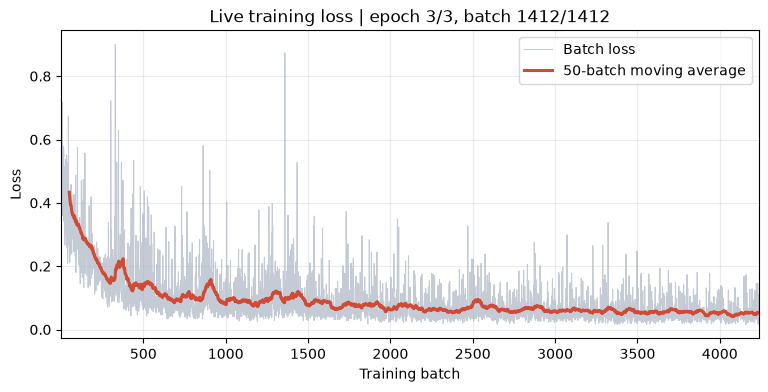

Epoch [1/3] - Batch [50/1412] - Loss: 0.3829
Epoch [1/3] - Batch [100/1412] - Loss: 0.5745
Epoch [1/3] - Batch [150/1412] - Loss: 0.2812
Epoch [1/3] - Batch [200/1412] - Loss: 0.2262
Epoch [1/3] - Batch [250/1412] - Loss: 0.1691
Epoch [1/3] - Batch [300/1412] - Loss: 0.1170
Epoch [1/3] - Batch [350/1412] - Loss: 0.2271
Epoch [1/3] - Batch [400/1412] - Loss: 0.2224
Epoch [1/3] - Batch [450/1412] - Loss: 0.0817
Epoch [1/3] - Batch [500/1412] - Loss: 0.0832
Epoch [1/3] - Batch [550/1412] - Loss: 0.0624
Epoch [1/3] - Batch [600/1412] - Loss: 0.2504
Epoch [1/3] - Batch [650/1412] - Loss: 0.0343
Epoch [1/3] - Batch [700/1412] - Loss: 0.0613
Epoch [1/3] - Batch [750/1412] - Loss: 0.1221
Epoch [1/3] - Batch [800/1412] - Loss: 0.0822
Epoch [1/3] - Batch [850/1412] - Loss: 0.0669
Epoch [1/3] - Batch [900/1412] - Loss: 0.0882
Epoch [1/3] - Batch [950/1412] - Loss: 0.0660
Epoch [1/3] - Batch [1000/1412] - Loss: 0.0538
Epoch [1/3] - Batch [1050/1412] - Loss: 0.0668
Epoch [1/3] - Batch [1100/1412] -

In [4]:
data_candidates = list(globals().get("candidate_dirs", []))
data_candidates.extend([
    r"C:\Users\jaidhev\Downloads\data",
    "/mnt/c/Users/jaidhev/Downloads/data",
])
if "data_dir" in globals() and isinstance(data_dir, (str, os.PathLike)):
    data_candidates.append(data_dir)

data_dir = next(
    (
        path for path in data_candidates
        if isinstance(path, (str, os.PathLike))
        and os.path.isdir(os.path.join(path, "clean"))
        and any(os.path.isdir(os.path.join(path, folder)) for folder in ("corr", "corrupted"))
        and any(os.path.isdir(os.path.join(path, folder)) for folder in ("masked", "masks"))
    ),
    None,
)
if data_dir is None:
    raise FileNotFoundError(
        "Dataset folders were not found. Expected clean, corrupted, and masks "
        "under C:\\Users\\jaidhev\\Downloads\\data."
    )

batch_size = 1
epochs = 3
dataset = MumbaiSatelliteDataset(data_dir)
total_samples = len(dataset)

if total_samples == 0:
    raise FileNotFoundError(f"No PNG files found in {os.path.join(data_dir, 'clean')}")

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=device.type == "cuda",
)
model = SatelliteInpaintingUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\n=========================================================")
print("   TRAINING ISRO NM391 MISSING DATA RECONSTRUCTION MODEL")
print(f"   Target Region: Mumbai | Total Patches: {total_samples}")
print(f"   Batch size: {batch_size} | Device: {device}")
print("=========================================================\n")

from IPython.display import display

batch_losses = []
plot_window = 50
fig, ax = plt.subplots(figsize=(9, 4))
batch_line, = ax.plot([], [], color="#a7b0bf", linewidth=0.8, alpha=0.65, label="Batch loss")
trend_line, = ax.plot([], [], color="#d04a35", linewidth=2.2, label="50-batch moving average")
ax.set_xlabel("Training batch")
ax.set_ylabel("Loss")
ax.set_title("Live training loss")
ax.grid(True, alpha=0.25)
ax.legend()
loss_plot = display(fig, display_id=True)

start_time = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    psnr_list = []

    for step, (inputs, targets, masks) in enumerate(train_loader, start=1):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = compute_inpainting_loss(outputs, targets, masks)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        batch_losses.append(batch_loss)
        running_loss += batch_loss * inputs.shape[0]
        for prediction, target in zip(outputs, targets):
            psnr_list.append(calculate_psnr(prediction, target))

        if step % 50 == 0 or step == len(train_loader):
            batch_numbers = np.arange(1, len(batch_losses) + 1)
            batch_line.set_data(batch_numbers, batch_losses)
            if len(batch_losses) >= plot_window:
                moving_average = np.convolve(
                    batch_losses,
                    np.ones(plot_window, dtype=np.float32) / plot_window,
                    mode="valid",
                )
                trend_line.set_data(
                    np.arange(plot_window, len(batch_losses) + 1),
                    moving_average,
                )
            ax.set_xlim(1, max(plot_window, len(batch_losses)))
            ax.relim()
            ax.autoscale_view(scalex=False, scaley=True)
            ax.set_title(f"Live training loss | epoch {epoch + 1}/{epochs}, batch {step}/{len(train_loader)}")
            loss_plot.update(fig)

            print(f"Epoch [{epoch + 1}/{epochs}] - Batch [{step}/{len(train_loader)}] - Loss: {batch_loss:.4f}")

    epoch_loss = running_loss / total_samples
    avg_psnr = float(np.mean(psnr_list))
    print(f"Epoch [{epoch + 1}/{epochs}] complete - Loss: {epoch_loss:.4f} | Avg PSNR: {avg_psnr:.2f} dB")

plt.close(fig)
total_time = time.time() - start_time
print(f"\nTraining completed in {total_time:.2f} seconds")
print(f"Final reconstruction quality: {avg_psnr:.2f} dB PSNR")

save_path = os.path.abspath(os.path.join(data_dir, "..", "mumbai_isro_unet.pth"))
torch.save({"model_state_dict": model.state_dict()}, save_path)
print(f"[Saved] PyTorch model saved to: {save_path}")

In [5]:
# Evaluate the trained model on the available data loader
eval_model = model.to(device)
eval_model.eval()

eval_loader = smoke_loader if "smoke_loader" in globals() else train_loader

losses = []
psnrs = []

with torch.inference_mode():
    for inputs, targets, masks in eval_loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        outputs = eval_model(inputs)
        loss = compute_inpainting_loss(outputs, targets, masks)
        losses.append(loss.item())

        for pred, gt in zip(outputs, targets):
            psnrs.append(calculate_psnr(pred, gt))

avg_loss = float(np.mean(losses))
avg_psnr = float(np.mean(psnrs))

print("=========================================================")
print("MODEL EVALUATION")
print(f"Samples tested: {len(psnrs)}")
print(f"Average loss: {avg_loss:.4f}")
print(f"Average PSNR: {avg_psnr:.2f} dB")
print("=========================================================")

# Optional: inspect one reconstructed example
sample_inputs, sample_targets, sample_masks = next(iter(eval_loader))
sample_inputs = sample_inputs.to(device)
sample_targets = sample_targets.to(device)
sample_masks = sample_masks.to(device)

with torch.inference_mode():
    sample_outputs = eval_model(sample_inputs)

sample_loss = compute_inpainting_loss(sample_outputs, sample_targets, sample_masks)
sample_psnr = calculate_psnr(sample_outputs[0], sample_targets[0])

print(f"Example loss: {sample_loss.item():.4f}")
print(f"Example PSNR: {sample_psnr:.2f} dB")

MODEL EVALUATION
Samples tested: 1412
Average loss: 0.0868
Average PSNR: 23.30 dB
Example loss: 0.0983
Example PSNR: 22.85 dB


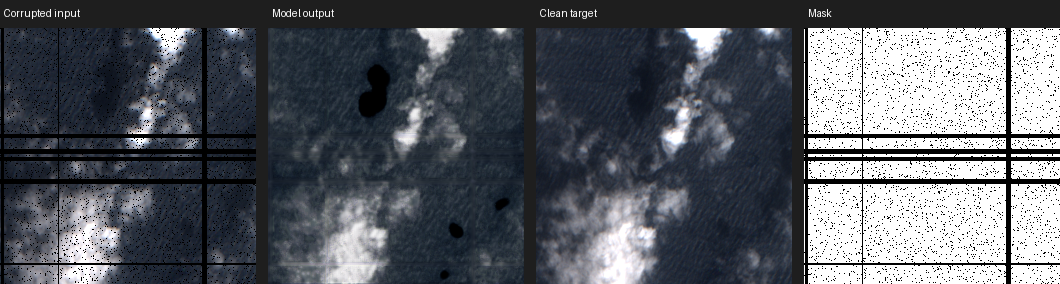

Sample PSNR: 25.57 dB


In [6]:
from IPython.display import display
from PIL import ImageDraw

demo_model = SatelliteInpaintingUNet().to(device)
demo_checkpoint = torch.load(save_path, map_location=device, weights_only=True)
demo_model.load_state_dict(demo_checkpoint["model_state_dict"])
demo_model.eval()

demo_input, demo_target, demo_mask = dataset[0]
with torch.inference_mode():
    demo_prediction = demo_model(demo_input.unsqueeze(0).to(device))[0].cpu()

def tensor_to_rgb_image(tensor):
    array = tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    return Image.fromarray((array * 255).round().astype(np.uint8))

corrupted_image = tensor_to_rgb_image(demo_input[:3])
prediction_image = tensor_to_rgb_image(demo_prediction)
target_image = tensor_to_rgb_image(demo_target)
mask_array = (demo_mask.squeeze(0).numpy().clip(0, 1) * 255).round().astype(np.uint8)
mask_image = Image.fromarray(mask_array).convert("RGB")

panels = [
    ("Corrupted input", corrupted_image),
    ("Model output", prediction_image),
    ("Clean target", target_image),
    ("Mask", mask_image),
]
image_width, image_height = corrupted_image.size
panel_gap = 12
label_height = 28
comparison = Image.new(
    "RGB",
    (len(panels) * image_width + (len(panels) - 1) * panel_gap, image_height + label_height),
    (30, 30, 30),
)
draw = ImageDraw.Draw(comparison)
for index, (label, image) in enumerate(panels):
    x = index * (image_width + panel_gap)
    draw.text((x + 4, 7), label, fill=(255, 255, 255))
    comparison.paste(image, (x, label_height))

display(comparison)
print(f"Sample PSNR: {calculate_psnr(demo_prediction, demo_target):.2f} dB")